## Analisis Polizas Reclamadas




### Entendimineto del negocio

La frecuencia siniestral es el principal componente del costo técnico de las aseguradoras de automóviles. Disponer de una estimación individual del riesgo permite:

*   Fortalecer el proceso de suscripción mediante criterios objetivos de aceptación y tarificación
*   Segmentar la cartera y ajustar la prima de riesgo al perfil real de cada asegurado, mitigando la selección adversa y el subsidio cruzado entre segmentos
*   Anticipar el comportamiento de la siniestralidad esperada y apoyar la constitución de reservas
*   Orientar estrategias diferenciadas de retención y renovación sobre los segmentos de mejor desempeño técnico.



## Entendimineto de los datos



### **Descripción de las variables**


| Categoría | Variable | Descripción |
|---|---|---|
| **Identificación** | `policy_id` | Identificador único de la póliza |
| **Póliza y asegurado** | `policy_tenure` | Antigüedad de la póliza |
|  | `age_of_car` | Edad del vehículo |
|  | `age_of_policyholder` | Edad del asegurado |
|  | `area_cluster` | Zona geográfica de la póliza |
|  | `population_density` | Densidad poblacional de la zona |
| **Vehículo** | `make` | Fabricante del vehículo (código) |
|  | `segment` | Segmento del vehículo |
|  | `model` | Modelo del vehículo |
|  | `fuel_type` | Tipo de combustible |
|  | `max_torque` | Torque máximo del motor |
|  | `max_power` | Potencia máxima del motor |
|  | `engine_type` | Tipo de motor |
|  | `displacement` | Cilindrada del motor |
|  | `cylinder` | Número de cilindros |
|  | `transmission_type` | Tipo de transmisión |
|  | `gear_box` | Número de marchas |
|  | `turning_radius` | Radio de giro |
|  | `length` | Longitud del vehículo |
|  | `width` | Ancho del vehículo |
|  | `height` | Altura del vehículo |
|  | `gross_weight` | Peso bruto del vehículo |
| **Seguridad y equipamiento** | `airbags` | Número de airbags |
|  | `is_esc` | Control electrónico de estabilidad |
|  | `is_adjustable_steering` | Dirección ajustable |
|  | `is_tpms` | Sensor de presión de llantas |
|  | `is_parking_sensors` | Sensores de estacionamiento |
|  | `is_parking_camera` | Cámara de reversa |
|  | `rear_brakes_type` | Tipo de frenos traseros |
|  | `steering_type` | Tipo de dirección |
|  | `is_front_fog_lights` | Luces antiniebla delanteras |
|  | `is_rear_window_wiper` | Limpiaparabrisas trasero |
|  | `is_rear_window_washer` | Lavador del vidrio trasero |
|  | `is_rear_window_defogger` | Desempañador del vidrio trasero |
|  | `is_brake_assist` | Asistencia de frenado |
|  | `is_power_door_locks` | Cierre eléctrico de puertas |
|  | `is_central_locking` | Cierre centralizado |
|  | `is_power_steering` | Dirección asistida |
|  | `is_driver_seat_height_adjustable` | Asiento del conductor ajustable en altura |
|  | `is_day_night_rear_view_mirror` | Espejo retrovisor día/noche |
|  | `is_ecw` | Advertencia de cinturón de seguridad |
|  | `is_speed_alert` | Alerta de velocidad |
|  | `ncap_rating` | Calificación de seguridad NCAP (0–5) |
| **Variable respuesta** | `is_claim` | 1 si hubo reclamación y 0 si no |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve

In [ ]:
df = pd.read_csv('test_estudiantes.csv')

In [ ]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,ID38216,0.973237,0.03,0.423077,C5,34738,3,C2,M4,Diesel,...,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3
1,ID03598,0.020455,0.04,0.538462,C10,73430,1,A,M1,CNG,...,No,No,No,No,Yes,No,No,No,Yes,0
2,ID32005,0.429325,0.01,0.394231,C7,6112,1,A,M1,CNG,...,No,No,No,No,Yes,No,No,No,Yes,0
3,ID20541,1.059081,0.02,0.307692,C13,5410,3,C2,M4,Diesel,...,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3
4,ID55339,0.083045,0.09,0.317308,C5,34738,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11719 entries, 0 to 11718
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         11719 non-null  object 
 1   policy_tenure                     11719 non-null  float64
 2   age_of_car                        11719 non-null  float64
 3   age_of_policyholder               11719 non-null  float64
 4   area_cluster                      11719 non-null  object 
 5   population_density                11719 non-null  int64  
 6   make                              11719 non-null  int64  
 7   segment                           11719 non-null  object 
 8   model                             11719 non-null  object 
 9   fuel_type                         11719 non-null  object 
 10  max_torque                        11719 non-null  object 
 11  max_power                         11719 non-null  object 
 12  engi

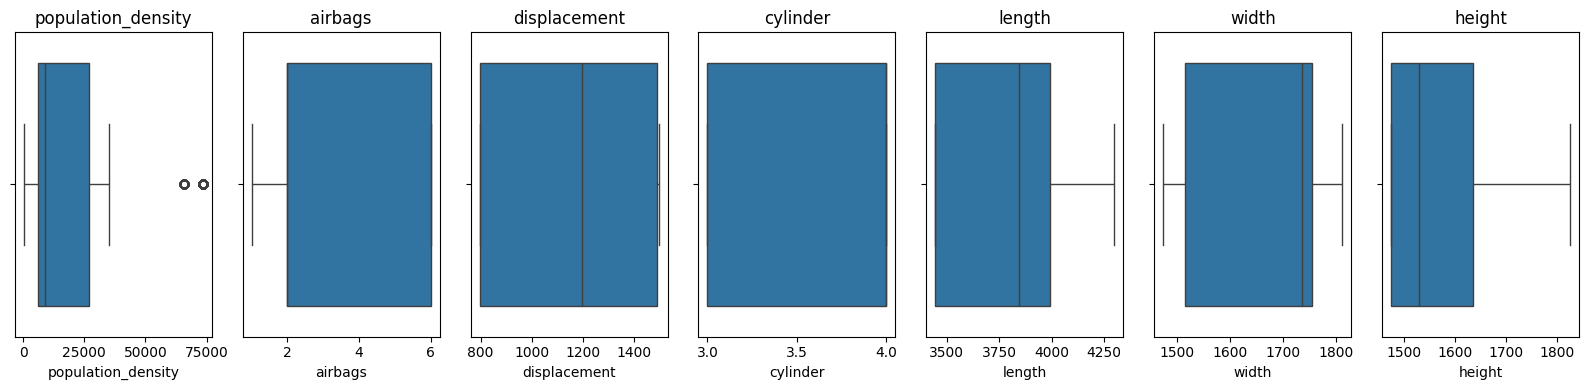

In [ ]:
variables = ["population_density", "airbags", "displacement", "cylinder","length","width","height"]

fig, axes = plt.subplots(1, len(variables), figsize=(16, 4))

for i, var in enumerate(variables):
    sns.boxplot(x=df[var], ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()